# Slike korištene u završnom radu

Ova bilježnica sadrži slike koje su korištene u 3. poglavlju završnog rada Izrada prototipa sustava za detekciju anomalija u financijskim sustavima u stvarnom vremenu primjenom metoda strojnog učenja.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

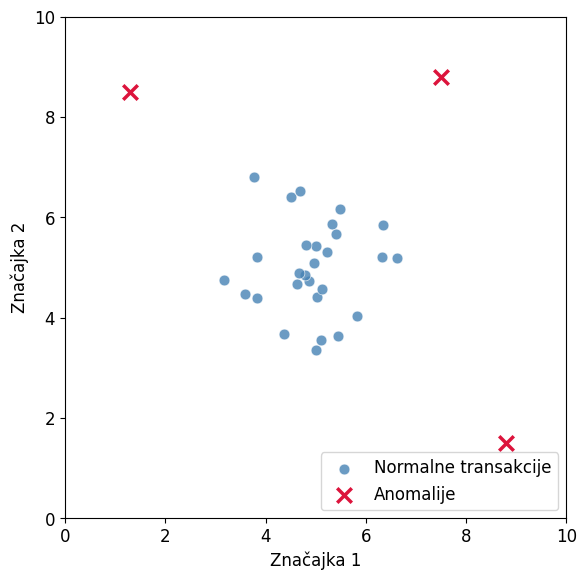

In [ ]:
from matplotlib.patches import Ellipse

np.random.seed(7)

# Gusta nakupina - normalne, legitimne transakcije
n_normal = 28
x_normal = np.random.normal(5, 0.8, n_normal)
y_normal = np.random.normal(5, 0.8, n_normal)

# Izolirane točke - anomalije
x_anomaly = np.array([8.8, 1.3, 7.5])
y_anomaly = np.array([1.5, 8.5, 8.8])

plt.figure(figsize=(6, 6))

plt.scatter(x_normal, y_normal, color='steelblue', s=60, alpha=0.8,
            edgecolors='white', linewidths=0.5, label='Normalne transakcije')
plt.scatter(x_anomaly, y_anomaly, color='crimson', marker='x', s=110,
            linewidths=2.5, label='Anomalije')

plt.xlabel('Značajka 1')
plt.ylabel('Značajka 2')
plt.legend(loc='lower right', frameon=True)
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.savefig('normal-vs-anomaly.png', dpi=300, bbox_inches='tight')
plt.show()

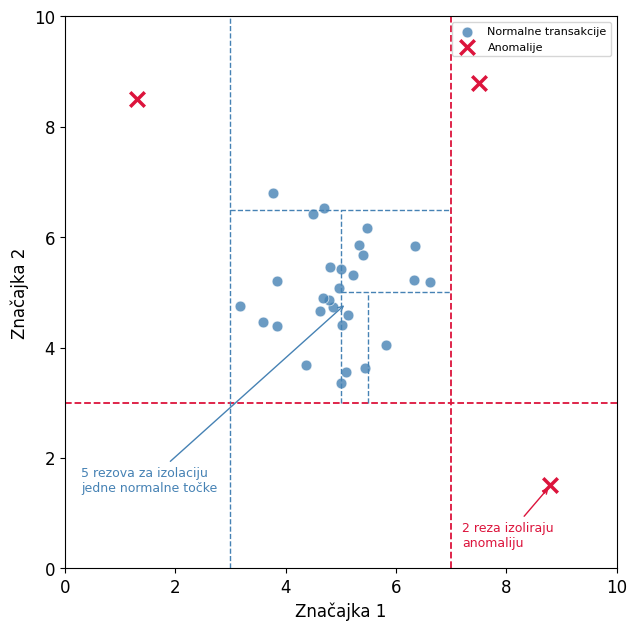

In [ ]:
import matplotlib.patches as mpatches

np.random.seed(7)

# Particioniranje prostora značajki
n_normal = 28
x_normal = np.random.normal(5, 0.8, n_normal)
y_normal = np.random.normal(5, 0.8, n_normal)
x_anomaly = np.array([8.8, 1.3, 7.5])
y_anomaly = np.array([1.5, 8.5, 8.8])

plt.figure(figsize=(6.5, 6.5))
ax = plt.gca()

ax.scatter(x_normal, y_normal, color='steelblue', s=60, alpha=0.8,
           edgecolors='white', linewidths=0.5, label='Normalne transakcije')
ax.scatter(x_anomaly, y_anomaly, color='crimson', marker='x', s=110,
           linewidths=2.5, label='Anomalije')

# Brza izolacija anomalije - samo 2 reza
ax.plot([7.0, 7.0], [0, 10], color='crimson', linestyle='--', linewidth=1.3)
ax.plot([0, 10], [3.0, 3.0], color='crimson', linestyle='--', linewidth=1.3)
ax.annotate('2 reza izoliraju\nanomaliju', xy=(8.8, 1.5), xytext=(7.2, 0.4),
            fontsize=9, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson'))

# Spora izolacija normalne točke unutar guste nakupine - 5 rezova
cuts = [
    ([3, 3], [0, 10]),
    ([3, 7], [6.5, 6.5]),
    ([5, 5], [3, 6.5]),
    ([5, 7], [5, 5]),
    ([5.5, 5.5], [3, 5]),
]
for (xs, ys) in cuts:
    ax.plot(xs, ys, color='steelblue', linestyle='--', linewidth=1)
ax.annotate('5 rezova za izolaciju\njedne normalne točke', xy=(5.1, 4.8), xytext=(0.3, 1.4),
            fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel('Značajka 1')
ax.set_ylabel('Značajka 2')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('iso-forest-arhitektura.png', dpi=300, bbox_inches='tight')
plt.show()

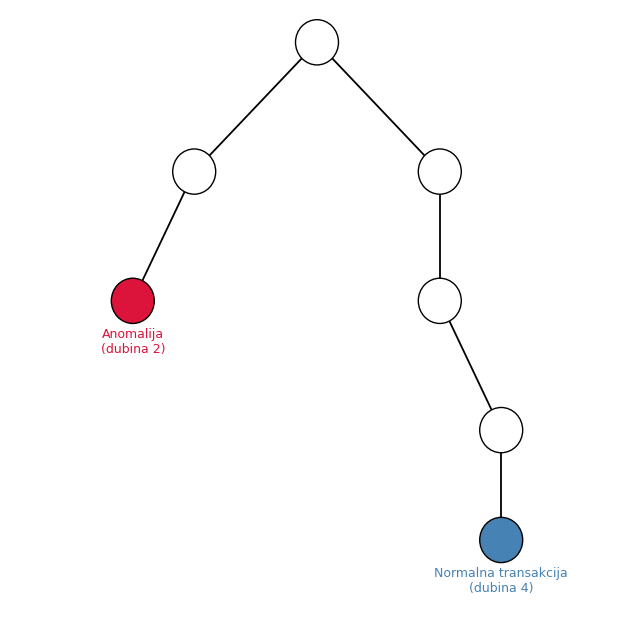

In [ ]:
# Duljina puta u izolacijskom stablu
plt.figure(figsize=(6.5, 6.5))
ax2 = plt.gca()
ax2.axis('off')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 9.5)

def node(x, y, color='white', edge='black', r=0.35):
    ax2.add_patch(mpatches.Circle((x, y), r, facecolor=color, edgecolor=edge, zorder=3))

def edge(x1, y1, x2, y2, color='black'):
    ax2.plot([x1, x2], [y1, y2], color=color, linewidth=1.3, zorder=1)

# Korijen
node(5, 9)

# Anomalija - kratak put (lijevo)
edge(5, 9, 3, 7); node(3, 7)
edge(3, 7, 2, 5); node(2, 5, color='crimson')
ax2.text(2, 4.2, 'Anomalija\n(dubina 2)', ha='center', fontsize=9, color='crimson')

# Normalna transakcija - dug put (desno)
edge(5, 9, 7, 7); node(7, 7)
edge(7, 7, 7, 5); node(7, 5)
edge(7, 5, 8, 3); node(8, 3)
edge(8, 3, 8, 1.3); node(8, 1.3, color='steelblue')
ax2.text(8, 0.5, 'Normalna transakcija\n(dubina 4)', ha='center', fontsize=9, color='steelblue')

plt.tight_layout()
plt.savefig('iso-forest-stablo.png', dpi=300, bbox_inches='tight')
plt.show()

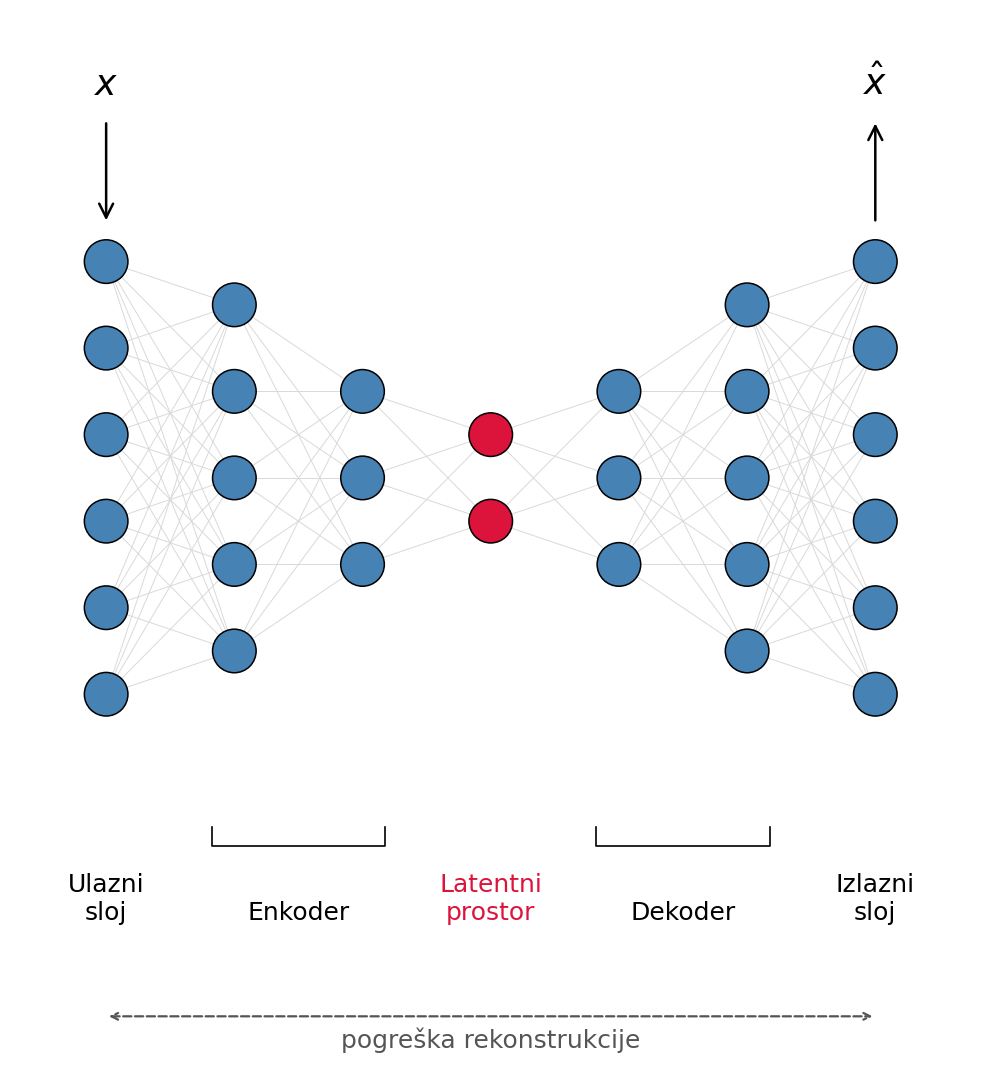

In [ ]:
import matplotlib.patches as mpatches

# Broj neurona po sloju: ulaz -> enkoder (2 skrivena sloja) -> latentni prostor -> dekoder (2 skrivena sloja) -> izlaz
layer_sizes = [6, 5, 3, 2, 3, 5, 6]
layer_x = np.linspace(1, 13, len(layer_sizes))

def layer_y(n, center=5, spacing=1.35):
    h = (n - 1) * spacing
    return [center + h/2 - i*spacing for i in range(n)]

positions = [layer_y(n) for n in layer_sizes]

fig, ax = plt.subplots(figsize=(17, 11))

# Veze između susjednih slojeva (tanke, svijetlosive)
for li in range(len(layer_sizes) - 1):
    x1, x2 = layer_x[li], layer_x[li + 1]
    for y1 in positions[li]:
        for y2 in positions[li + 1]:
            ax.plot([x1, x2], [y1, y2], color='#d9d9d9', linewidth=0.7, zorder=1)

# Neuroni (čvorovi) - latentni prostor istaknut drugom bojom
node_color = ['steelblue', 'steelblue', 'steelblue', 'crimson', 'steelblue', 'steelblue', 'steelblue']
for x, ys, c in zip(layer_x, positions, node_color):
    for y in ys:
        ax.add_patch(mpatches.Circle((x, y), 0.34, facecolor=c, edgecolor='black',
                                      linewidth=1.1, zorder=2))

# Oznake slojeva (ispod)
ax.text(layer_x[0], -1.9, 'Ulazni\nsloj', ha='center', fontsize=18)
ax.text((layer_x[1] + layer_x[2]) / 2, -1.9, 'Enkoder', ha='center', fontsize=18)
ax.text(layer_x[3], -1.9, 'Latentni\nprostor', ha='center', fontsize=18, color='crimson')
ax.text((layer_x[4] + layer_x[5]) / 2, -1.9, 'Dekoder', ha='center', fontsize=18)
ax.text(layer_x[6], -1.9, 'Izlazni\nsloj', ha='center', fontsize=18)

# Zagrade (uglate linije) ispod enkodera i dekodera
def bracket(x_start, x_end, y=-0.75, drop=0.3):
    ax.plot([x_start, x_start, x_end, x_end], [y + drop, y, y, y + drop],
             color='black', linewidth=1.2)

bracket(layer_x[1] - 0.35, layer_x[2] + 0.35)
bracket(layer_x[4] - 0.35, layer_x[5] + 0.35)

# Ulazni vektor x i rekonstruirani izlaz x̂ (iznad)
ax.annotate('', xy=(layer_x[0], max(positions[0]) + 0.6),
            xytext=(layer_x[0], max(positions[0]) + 2.2),
            arrowprops=dict(arrowstyle='->', color='black', linewidth=1.8, mutation_scale=25))
ax.text(layer_x[0], max(positions[0]) + 2.6, r'$x$', ha='center', fontsize=26)

ax.annotate('', xy=(layer_x[6], max(positions[6]) + 2.2),
            xytext=(layer_x[6], max(positions[6]) + 0.6),
            arrowprops=dict(arrowstyle='->', color='black', linewidth=1.8, mutation_scale=25))
ax.text(layer_x[6], max(positions[6]) + 2.6, r'$\hat{x}$', ha='center', fontsize=26)

# Pogreška rekonstrukcije
y_err = -3.4
ax.annotate('', xy=(layer_x[6], y_err), xytext=(layer_x[0], y_err),
            arrowprops=dict(arrowstyle='<->', color='#555555', linestyle='--', linewidth=1.6))
ax.text((layer_x[0] + layer_x[6]) / 2, y_err - 0.5,
        'pogreška rekonstrukcije', ha='center', fontsize=18, color='#555555')

ax.set_xlim(-0.5, 14.5)
ax.set_ylim(-4.3, 12.3)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig('ae-arhitektura.png', dpi=300, bbox_inches='tight')
plt.show()


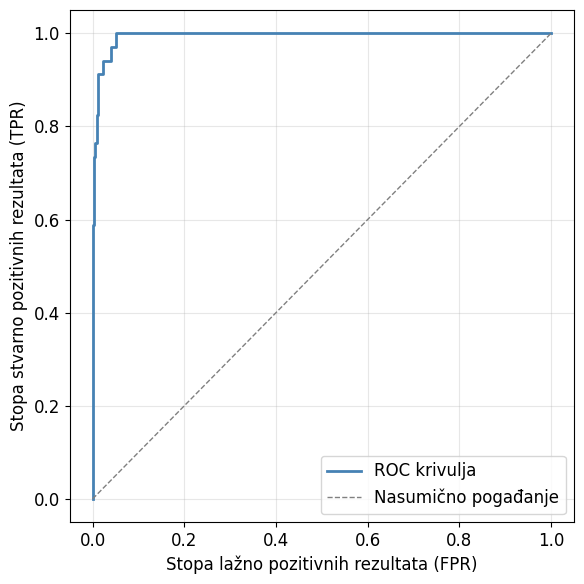

ROC AUC: 0.994


In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

np.random.seed(42)

# Ilustrativni podatci koji oponašaju omjer klasa iz stvarnog skupa podataka
# (Kaggle "Credit Card Fraud Detection": ~0,17% transakcija su prijevare)
n_legit = 20000
n_fraud = 34  # ~0,17% udio, kao u stvarnom skupu

# Simulacija anomalijskih rezultata modela (npr. izolacijska stabla / autoenkoder)
scores_legit = np.random.beta(2, 8, n_legit)   # legitimne - niži rezultati
scores_fraud = np.random.beta(6, 3, n_fraud)   # prijevare - viši rezultati, uz realno preklapanje

y_true = np.concatenate([np.zeros(n_legit), np.ones(n_fraud)])
y_scores = np.concatenate([scores_legit, scores_fraud])

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_true, y_scores)
pr_auc = average_precision_score(y_true, y_scores)

# ROC krivulja
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC krivulja')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Nasumično pogađanje')
plt.xlabel('Stopa lažno pozitivnih rezultata (FPR)')
plt.ylabel('Stopa stvarno pozitivnih rezultata (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc-krivulja-primjer.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"ROC AUC: {roc_auc:.3f}")

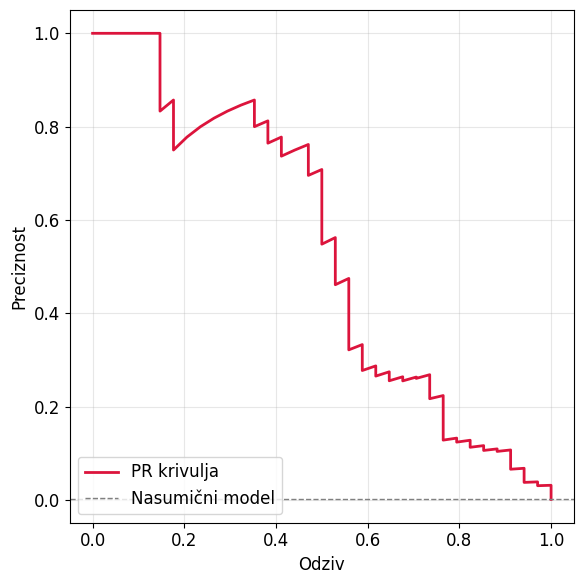

PR AUC: 0.538


In [ ]:
# PR krivulja
plt.figure(figsize=(6, 6))
plt.plot(recall, precision, color='crimson', linewidth=2, label=f'PR krivulja')
baseline = n_fraud / (n_fraud + n_legit)
plt.axhline(y=baseline, color='gray', linestyle='--', linewidth=1, label=f'Nasumični model')
plt.xlabel('Odziv')
plt.ylabel('Preciznost')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr-krivulja-primjer.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"PR AUC: {pr_auc:.3f}")

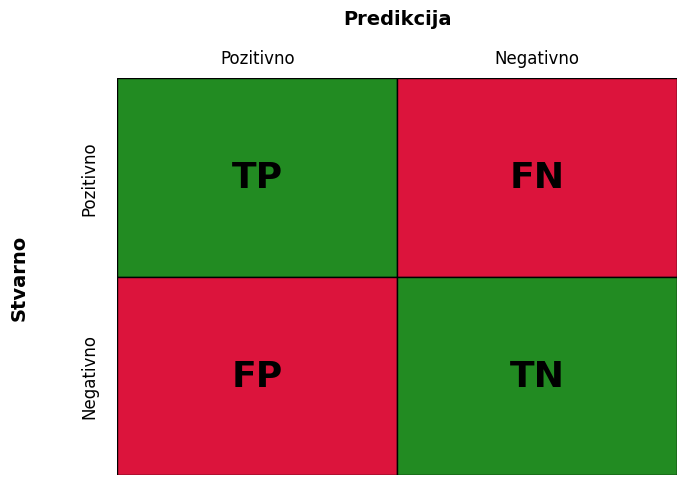

In [15]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis('off')

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)

color_true = 'forestgreen'   # Zelena za ispravne klasifikacije
color_false = 'crimson'  # Crvena za pogreške

ax.add_patch(patches.Rectangle((0, 1), 1, 1, facecolor=color_true, edgecolor='black', linewidth=1))
ax.add_patch(patches.Rectangle((1, 1), 1, 1, facecolor=color_false, edgecolor='black', linewidth=1))
ax.add_patch(patches.Rectangle((0, 0), 1, 1, facecolor=color_false, edgecolor='black', linewidth=1))
ax.add_patch(patches.Rectangle((1, 0), 1, 1, facecolor=color_true, edgecolor='black', linewidth=1))

ax.text(0.5, 1.5, 'TP', ha='center', va='center', fontsize=26, fontweight='bold')
ax.text(1.5, 1.5, 'FN', ha='center', va='center', fontsize=26, fontweight='bold')
ax.text(0.5, 0.5, 'FP', ha='center', va='center', fontsize=26, fontweight='bold')
ax.text(1.5, 0.5, 'TN', ha='center', va='center', fontsize=26, fontweight='bold')

ax.text(1, 2.3, 'Predikcija', ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(0.5, 2.1, 'Pozitivno', ha='center', va='center', fontsize=12)
ax.text(1.5, 2.1, 'Negativno', ha='center', va='center', fontsize=12)

ax.text(-0.35, 1, 'Stvarno', ha='center', va='center', fontsize=14, fontweight='bold', rotation=90)
ax.text(-0.1, 1.5, 'Pozitivno', ha='center', va='center', fontsize=12, rotation=90)
ax.text(-0.1, 0.5, 'Negativno', ha='center', va='center', fontsize=12, rotation=90)

plt.tight_layout()
plt.savefig('confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()